In [1]:
%load_ext autoreload
%autoreload 2
from helpers import *
from SINDyModel import *

In [2]:
def generate_noise_level_vs_dt_matrix(rhs, x0, t_span, noise_levels, dts, threshold, poly_order, generate_prediction=True):
    data = []

    for dt in dts:
        print(f"dt: {dt}")

        for noise_level in tqdm(noise_levels):
            data_entry = {}
            data_entry["dt"] = dt
            data_entry["noise_level"] = noise_level

            # generate evaluation time points
            t_eval = np.arange(t_span[0], t_span[1] + dt, dt)
            data_entry["t_eval"] = t_eval

            # generate training data
            x_train = generate_training_data(rhs, x0, t_eval)
            data_entry["x_train"] = x_train
            
            # generate noisy data
            x_train_noisy = add_noise_to_data(x_train, noise_level)
            # data_entry["x_train_noisy"] = x_train_noisy

            # generate the derivative of the noisy data
            x_dot_approx = dxdt(x_train_noisy, t_eval, kind="finite_difference", k=1)
            # data_entry["x_dot_approx"] = x_dot_approx

            # create and fit a SINDy model
            model = SINDyModel(n_state_vars=len(x0), threshold=threshold, poly_order=poly_order)
            model.fit(x_train_noisy, x_dot_approx)
            data_entry["model"] = model

            # generate the model prediction if needed
            if generate_prediction is True:
                x_pred = generate_model_prediction(model, x0, t_eval)
                data_entry["x_pred"] = x_pred
            
            # store the data entry
            data.append(data_entry)
        
    return data


lotka_volterra_rhs = generate_lotka_volterra_rhs(1, 0.1, 1.5, 0.75)

# noise_levels = [0, 0.0001, 0.001, 0.01, 0.05, 0.1, 0.2, 1]
# dts = [0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1]
noise_levels = np.logspace(-4, 0, 10).tolist()
dts = np.logspace(-2, 0, 10).tolist()

data = generate_noise_level_vs_dt_matrix(
    rhs=lotka_volterra_rhs,
    x0=(10, 5),
    t_span=(0, 50),
    noise_levels=noise_levels,
    dts=dts,
    threshold=0.02,
    poly_order=5,
    generate_prediction=False
)


dt: 0.01


100%|██████████| 10/10 [00:03<00:00,  3.19it/s]


dt: 0.016681005372000592


100%|██████████| 10/10 [00:02<00:00,  4.40it/s]


dt: 0.027825594022071243


...

100%|██████████| 10/10 [00:00<00:00, 23.84it/s]


dt: 0.5994842503189409


100%|██████████| 10/10 [00:00<00:00, 25.93it/s]


dt: 1.0


100%|██████████| 10/10 [00:00<00:00, 28.30it/s]


In [3]:
# make a matrix of the relative coefficient errors

# (very janky) set up the true coefficients
true_coeffs = np.zeros((21, 2))
true_coeffs[1, 0] = 1
true_coeffs[2, 0] = -0.1
true_coeffs[2, 1] = 0.75
true_coeffs[16, 1] = -1.5

rce_mtx = np.zeros((len(noise_levels), len(dts)))

for data_entry in data:    
    model = data_entry["model"]

    rce = relative_coefficient_error(model.Xi, true_coeffs)

    dt_idx = dts.index(data_entry["dt"])
    noise_level_idx = noise_levels.index(data_entry["noise_level"])
    rce_mtx[noise_level_idx, dt_idx] = rce

# rce_mtx

[Text(0.5, 65.44999999999999, 'dt'),
 Text(80.45, 0.5, 'noise level'),
 Text(0.5, 1.0, 'Relative Coefficient Error')]

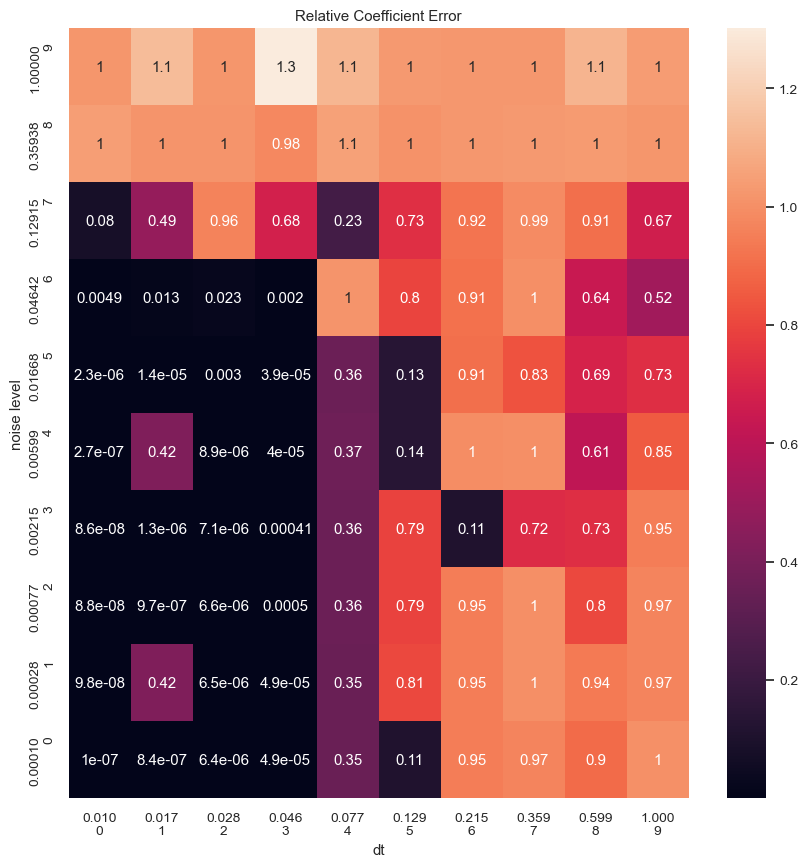

In [4]:
import seaborn as sns

fig = plt.figure(figsize=(10, 10))

sns.set_theme(font_scale=0.9)
ax = sns.heatmap(rce_mtx[::-1, :], annot=True,
                 xticklabels=[f"{dt:.3f}\n{i}" for i, dt in enumerate(dts)],
                 yticklabels=[f"{noise_level:.5f}\n{i}" for i, noise_level in list(enumerate(noise_levels))[::-1]])

ax.set(xlabel='dt', ylabel='noise level', title="Relative Coefficient Error")

In [11]:
# make a matrix of the relative trajectory errors

rte_mtx = np.zeros((len(noise_levels), len(dts)))

for data_entry in data:    
    x_train = data_entry["x_train"]
    x_pred = data_entry["x_pred"]

    # calculate the relative trajectory error
    # if the model prediction is "None", set the rte to np.nan
    if x_pred is None:
        rte = np.nan
    else:
        rte = relative_trajectory_error(x_train, x_pred)
    
    dt_idx = dts.index(data_entry["dt"])
    noise_level_idx = noise_levels.index(data_entry["noise_level"])
    rte_mtx[noise_level_idx, dt_idx] = rte

# rte_mtx

[Text(0.5, 65.44999999999999, 'dt'),
 Text(80.45, 0.5, 'noise level'),
 Text(0.5, 1.0, 'Relative Trajectory Error')]

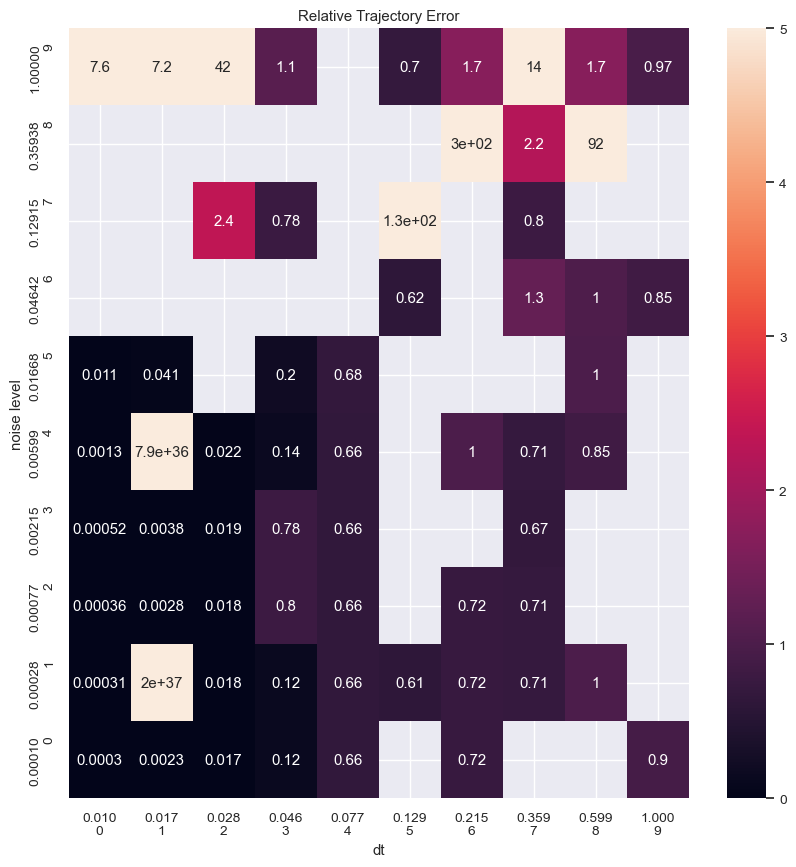

In [15]:
import seaborn as sns

fig = plt.figure(figsize=(10, 10))

sns.set_theme(font_scale=0.9)
ax = sns.heatmap(rte_mtx[::-1, :], annot=True, vmin=0, vmax=5,
                 xticklabels=[f"{dt:.3f}\n{i}" for i, dt in enumerate(dts)],
                 yticklabels=[f"{noise_level:.5f}\n{i}" for i, noise_level in list(enumerate(noise_levels))[::-1]])

ax.set(xlabel='dt', ylabel='noise level', title='Relative Trajectory Error')

In [12]:
# set the indices of the data entry you'd like to explore
dt_idx = 5
noise_level_idx = 2

# find the data entry with the specified dt and noise level
data_entry = None
for de in data:
    if de["dt"] == dts[dt_idx] and de["noise_level"] == noise_levels[noise_level_idx]:
        data_entry = de

# extract the relevant data from the data entry
t_eval = data_entry['t_eval']
x_train = data_entry['x_train']
x_pred = data_entry['x_pred']

# print the model
model = data_entry['model']
model.print()

n_state_vars = x_train.shape[0]

# plot the training data and model prediction
fig, axs = plt.subplots(1, n_state_vars, figsize=(10, 5), sharex='col', sharey='row')

for sv in range(n_state_vars):
    # plot the col'th training state variable
    axs[sv].plot(t_eval, x_train[sv], "r", label="train")

    # plot the col'th state variable model prediction
    axs[sv].plot(t_eval, x_pred[sv], "k--", label="prediction")

    # set labels
    axs[sv].set_xlabel("t")
    axs[sv].set_ylabel(f"$x_{sv}$")
    axs[sv].legend()

KeyError: 'x_pred'

x0' = + -0.10525 1 + 1.12528 x0 + -0.09525 x0 x1 + -0.02051 x0^2 
x1' = + -1.61547 1 + 3.19196 x0 + 0.69507 x0 x1 + -0.97040 x0^2 + 0.07420 x0^3 + -1.39037 x1 


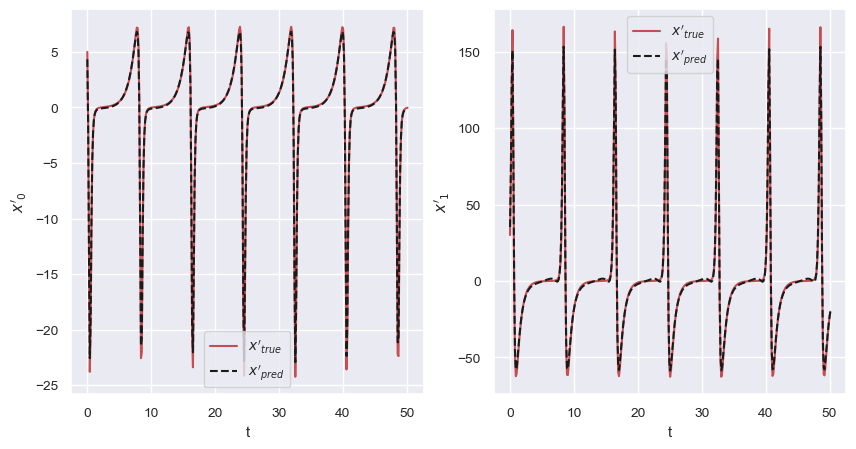

In [16]:
# THIS IS A TMP CELL! JUST ADDING THIS TO DO A QUICK TEST!

# set the indices of the data entry you'd like to explore
dt_idx = 5
noise_level_idx = 2

# find the data entry with the specified dt and noise level
data_entry = None
for de in data:
    if de["dt"] == dts[dt_idx] and de["noise_level"] == noise_levels[noise_level_idx]:
        data_entry = de

# extract the relevant data from the data entry
t_eval = data_entry['t_eval']
x_train = data_entry['x_train']

x_dot_true = generate_true_derivative(lotka_volterra_rhs, x_train)
x_dot_pred = data_entry['model'].predict(x_train)

# print the model
model = data_entry['model']
model.print()

n_state_vars = x_dot_true.shape[0]

# plot the training data and model prediction
fig, axs = plt.subplots(1, n_state_vars, figsize=(10, 5))

for sv in range(n_state_vars):
    axs[sv].plot(t_eval, x_dot_true[sv], "r", label="$x'_{true}$")
    axs[sv].plot(t_eval, x_dot_pred[sv], "k--", label="$x'_{pred}$")

    # set labels
    axs[sv].set_xlabel("t")
    axs[sv].set_ylabel(f"$x'_{sv}$")
    axs[sv].legend()